<a href="https://colab.research.google.com/github/dyjdlopez/mapua_ieemg_decision_science/blob/main/IE151P-S/Module%2001/01_03_distribution_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01-03: Distribution Analysis

**IE151P-S — Advanced Computer Applications**
Companion notebook to Lesson 1.4 (Cross-Sectional Analysis: Features, Distribution, and Correlation)

---

This notebook covers **Distribution & Frequency Analysis** — central tendency, discrete vs. continuous histograms, multimodality, skewness/kurtosis, and the core distribution-visualization toolkit (histogram, KDE, boxplot, catplot). It ends with a short preview of two-dimensional frequency analysis, which is where **Notebook 01-04: Correlation Analysis** picks up.

Throughout, we compute things two ways where it helps: **by hand** (so the formula isn't a black box) and **with the library function** (so you know the tool you'll actually use). We also always follow a plot with a short **interpretation** — a graph you can't read is just decoration.

## Setup

We'll use:
- **pandas** — data loading and manipulation
- **numpy** — numerical computation
- **matplotlib** — the foundational plotting library
- **seaborn** — a higher-level plotting library built on top of matplotlib (more on this below)
- **scipy.stats** — statistical functions (skewness, kurtosis, distribution fitting)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent plot styling for this notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## Loading the Data: Palmer Penguins

We'll use the **Palmer Penguins** dataset — the same dataset from Lesson 1.4's Features section and multimodality example. It contains physical measurements for 344 penguins across three species (Adelie, Chinstrap, Gentoo), collected on three islands in the Palmer Archipelago, Antarctica.

> Data source: Gorman, K.B., Williams, T.D., Fraser, W.R. (2014). *PLoS ONE* 9(3). Package citation: Horst, A.M., Hill, A.P., Gorman, K.B. (2020). `palmerpenguins` R package.

We load it directly from its GitHub source as a CSV (avoids needing the `palmerpenguins` package).


In [2]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
penguins = pd.read_csv(url)
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
penguins.describe(include="all")


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,344,344,342.000000,342.000000,342.000000,342.000000,333,344.000000
unique,3,3,NaN,NaN,NaN,NaN,2,NaN
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,male,NaN
freq,152,168,NaN,NaN,NaN,NaN,168,NaN
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN,2008.029070
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN,0.818356
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN,2007.000000
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN,2007.000000
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN,2008.000000
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN,2009.000000


In [4]:
penguins.dtypes


,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


**Recall from Lesson 1.4 (Features):** each **column** here is a feature (`species`, `island`, `bill_length_mm`, ...), and each **row** is one observation (one penguin). Notice `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g` are `float64` (continuous, numeric) while `species`, `island`, and `sex` are categorical text, and `year` is a whole-number (`int64`) feature. We'll lean on that distinction below.

Also notice a few `NaN` values in the numeric columns above — a few penguins have missing measurements. We'll drop those on a column-by-column basis as needed rather than dropping whole rows, so we don't lose more data than necessary.


## A Note on Seaborn

You'll see two plotting libraries in this notebook: **matplotlib** and **seaborn**.

- **matplotlib** is the foundational Python plotting library. It's powerful and fully customizable, but often verbose — you build a plot piece by piece.
- **seaborn** is built *on top of* matplotlib. It knows how to work directly with pandas DataFrames (you hand it column names instead of raw arrays), and it ships with better default styling and built-in statistical plot types (KDE, boxplots, regression lines) that would take several lines of matplotlib to reproduce.

**They are not competitors** — a seaborn plot *is* a matplotlib figure underneath, so anything you know about customizing matplotlib plots (titles, axis labels, figure size) still applies. Think of seaborn as a set of convenient shortcuts for the plots you'll draw most often in data analysis.

Let's see the same histogram built both ways.


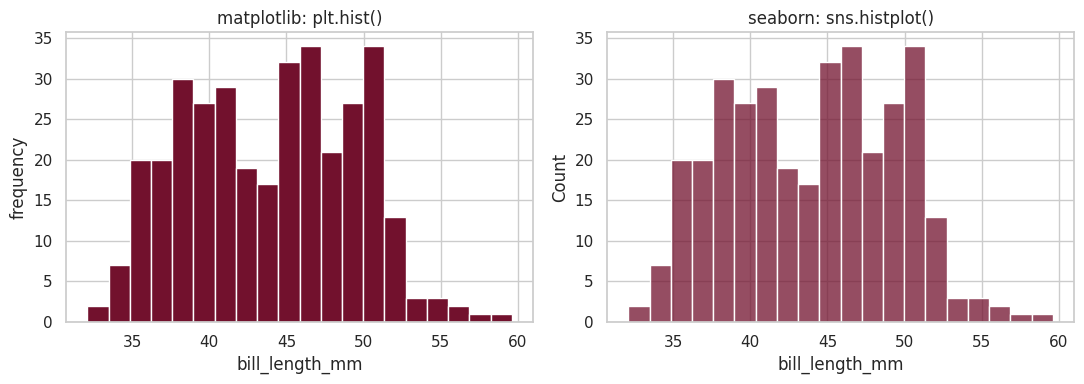

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# matplotlib: works with raw arrays, more manual setup
axes[0].hist(penguins["bill_length_mm"].dropna(), bins=20, color="#72112D", edgecolor="white")
axes[0].set_title("matplotlib: plt.hist()")
axes[0].set_xlabel("bill_length_mm")
axes[0].set_ylabel("frequency")

# seaborn: works directly with the DataFrame and column names
sns.histplot(data=penguins, x="bill_length_mm", bins=20, color="#72112D", ax=axes[1])
axes[1].set_title("seaborn: sns.histplot()")

plt.tight_layout()
plt.show()


**Interpretation:** same data, same shape — the seaborn version took a DataFrame and a column *name* rather than a raw array, and needed less manual styling to look clean. From here on, we'll mostly reach for seaborn, but you'll still see matplotlib underneath (`plt.subplots`, `plt.tight_layout`, etc.) doing the actual figure management.


## Central Tendency

Recall: **mean** (arithmetic average), **median** (middle value when sorted), **mode** (most frequent value). Let's compute all three for `bill_length_mm` two ways: by hand, and with pandas' built-in methods.

*A quick preview of the theme running through this notebook: computing a number is one thing, but choosing the right **plot** to compare that number across groups is a separate skill. We'll get to the plot best suited for comparing central tendency — the boxplot — later on.*


In [6]:
bill_length = penguins["bill_length_mm"].dropna()

# --- By hand ---
n = len(bill_length)
mean_by_hand = sum(bill_length) / n

sorted_vals = sorted(bill_length)
mid = n // 2
median_by_hand = sorted_vals[mid] if n % 2 == 1 else (sorted_vals[mid - 1] + sorted_vals[mid]) / 2

# Mode by hand: the value that occurs most often
counts = bill_length.value_counts()
mode_by_hand = counts.idxmax()

print("By hand:")
print(f"  mean   = {mean_by_hand:.3f}")
print(f"  median = {median_by_hand:.3f}")
print(f"  mode   = {mode_by_hand:.3f}")

# --- With pandas ---
print("\nWith pandas:")
print(f"  mean   = {bill_length.mean():.3f}")
print(f"  median = {bill_length.median():.3f}")
print(f"  mode   = {bill_length.mode()[0]:.3f}")


By hand:
  mean   = 43.922
  median = 44.450
  mode   = 41.100

With pandas:
  mean   = 43.922
  median = 44.450
  mode   = 41.100


**Interpretation:** the hand-computed and pandas values match, confirming the formulas are doing exactly what we expect. Mean and median are close together here (a few millimeters apart) — a first hint that `bill_length_mm` is close to symmetric, not heavily skewed. We'll check that formally with skewness below.


## Frequency Analysis: Discrete vs. Continuous Histograms

Not all frequency plots look the same, because not all features are the same *type*. Let's compare:

- **`year`** — a **discrete** numeric feature. Every penguin was recorded in exactly 2007, 2008, or 2009 — there's no such thing as "2007.5". The bars for a discrete feature should have **visible gaps** between them, because the values in between genuinely don't exist.
- **`bill_length_mm`** — a **continuous** numeric feature. It can take *any* value in a range (38.2mm, 38.23mm, 38.234mm, ...). A histogram bins continuous data into ranges, and the bars are drawn **touching**, because the bins tile the whole range with no genuine gaps.


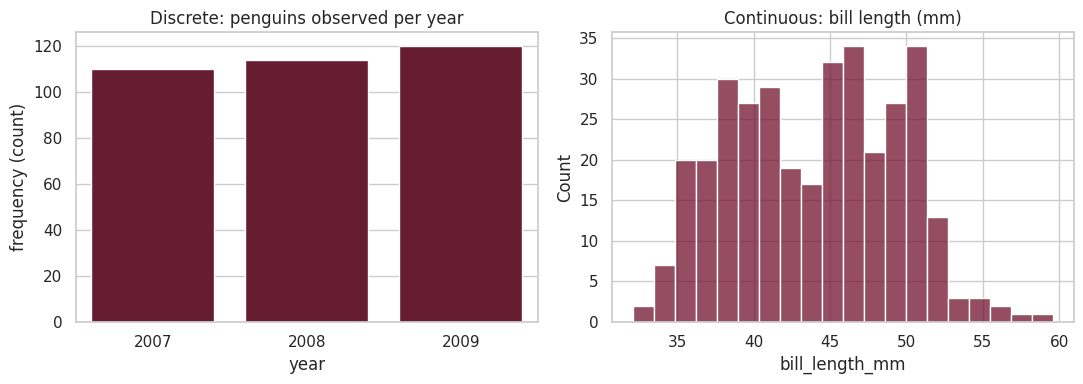

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Discrete: year -- use a count plot, bars have gaps
sns.countplot(data=penguins, x="year", color="#72112D", ax=axes[0])
axes[0].set_title("Discrete: penguins observed per year")
axes[0].set_xlabel("year")
axes[0].set_ylabel("frequency (count)")

# Continuous: bill_length_mm -- use a histogram, bars touch
sns.histplot(data=penguins, x="bill_length_mm", bins=20, color="#72112D", ax=axes[1])
axes[1].set_title("Continuous: bill length (mm)")

plt.tight_layout()
plt.show()


**Interpretation:** the year plot has three separate, gapped bars — there is no meaningful value "between" 2007 and 2008, so nothing should be drawn there. The bill-length plot instead has contiguous bars covering a continuous range of millimeter values, binned into equal-width intervals. Using a gapped bar chart for continuous data would misleadingly suggest the values are categories; using a touching histogram for discrete year data would misleadingly suggest fractional years exist. The plot type should match what the data actually *is*.


## Multimodality

Recall from Lesson 1.4: a distribution is **multimodal** when it has more than one peak — more than one "typical" value. Let's look at `body_mass_g` for all penguins combined, then split by `species`, recreating the lecture example.


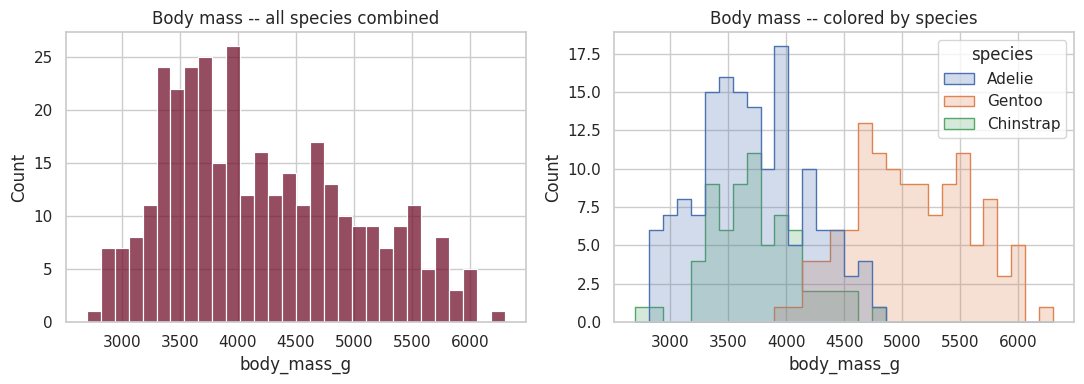

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# All penguins combined
sns.histplot(data=penguins, x="body_mass_g", bins=30, color="#72112D", ax=axes[0])
axes[0].set_title("Body mass -- all species combined")

# Split by species
sns.histplot(data=penguins, x="body_mass_g", hue="species", bins=30,
             element="step", ax=axes[1])
axes[1].set_title("Body mass -- colored by species")

plt.tight_layout()
plt.show()


**Interpretation:** the combined histogram on the left already hints at more than one bump, but it's not obvious *why*. Splitting by species on the right reveals the real structure: Adelie and Chinstrap penguins cluster at lower body mass, while Gentoo penguins cluster distinctly higher. Three species mixed together, three peaks — exactly the lecture's multimodality example. A single mean of `body_mass_g` would blur three genuinely different populations into one number.

**This is a match between technique and question.** Overlaid or `hue`-split histograms (and KDEs) are the right tool when you suspect multimodality, because they let separate peaks stay visible. A boxplot, by contrast, collapses each group down to five numbers (min, $Q_1$, median, $Q_3$, max) — it would tell you Gentoo penguins are heavier *on average*, but it cannot tell you a group's distribution has more than one peak at all. We'll see that limitation directly when we get to boxplots below.

## Skewness & Kurtosis

We'll compute both with `scipy.stats`, on `bill_length_mm` (all species combined, since we're not splitting by group here).


In [9]:
skewness = stats.skew(bill_length)
kurt = stats.kurtosis(bill_length)  # excess kurtosis (0 = normal-like)

print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis (excess): {kurt:.3f}")


Skewness: 0.053
Kurtosis (excess): -0.881


**Interpretation:** skewness ($\approx 0.05$) is close to 0, confirming the distribution is close to symmetric — matching what we already noticed when mean and median came out close together.

Kurtosis is a different story: excess kurtosis $\approx -0.88$ is **not** close to 0. A negative value means the distribution is **platykurtic** — flatter than a normal distribution, with lighter tails (fewer extreme values than a Gaussian would predict). This makes sense once you recall the multimodality section above: `bill_length_mm` isn't drawn from one clean bell curve, it's a mix of three species with different typical bill lengths, which tends to flatten and widen the combined shape compared to a true Gaussian. Worth sitting with this rather than rounding it away — the data is telling us something real.

Let's check that visually by fitting a Gaussian curve to the data and overlaying it on the histogram — a nice way to "demystify" what a distribution *shape* claim actually looks like against real numbers.


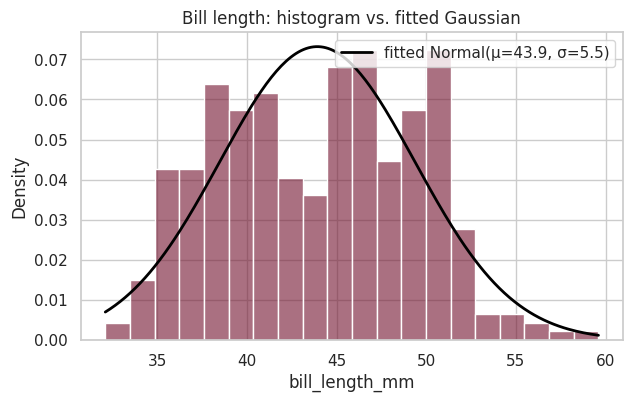

In [10]:
mu, sigma = stats.norm.fit(bill_length)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(bill_length, bins=20, stat="density", color="#72112D", alpha=0.6, ax=ax)

x = np.linspace(bill_length.min(), bill_length.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2,
        label=f"fitted Normal(μ={mu:.1f}, σ={sigma:.1f})")
ax.set_title("Bill length: histogram vs. fitted Gaussian")
ax.legend()
plt.show()


**Interpretation:** the fitted curve follows the general shape but doesn't nail it — notice the real histogram is a bit flatter and wider than the fitted bell curve, consistent with the negative excess kurtosis we just computed. This is exactly the kind of honest result worth sitting with rather than smoothing over: the Gaussian *approximation* is a reasonable working assumption for this feature, but it is an approximation, not a claim that penguin bill lengths were literally generated by a Normal distribution.


## Distribution Graphs: Histogram + KDE

Recall the KDE (Kernel Density Estimate) smooths a histogram into a continuous curve, controlled by a **bandwidth** parameter. Let's see the effect of bandwidth directly, since it's easy to under- or over-smooth.

Histograms and KDEs are both **shape-revealing** tools — they're what you reach for when the question is "what does this distribution look like" (symmetric? skewed? one peak or several?), as opposed to "what's the typical value" or "how do groups compare."


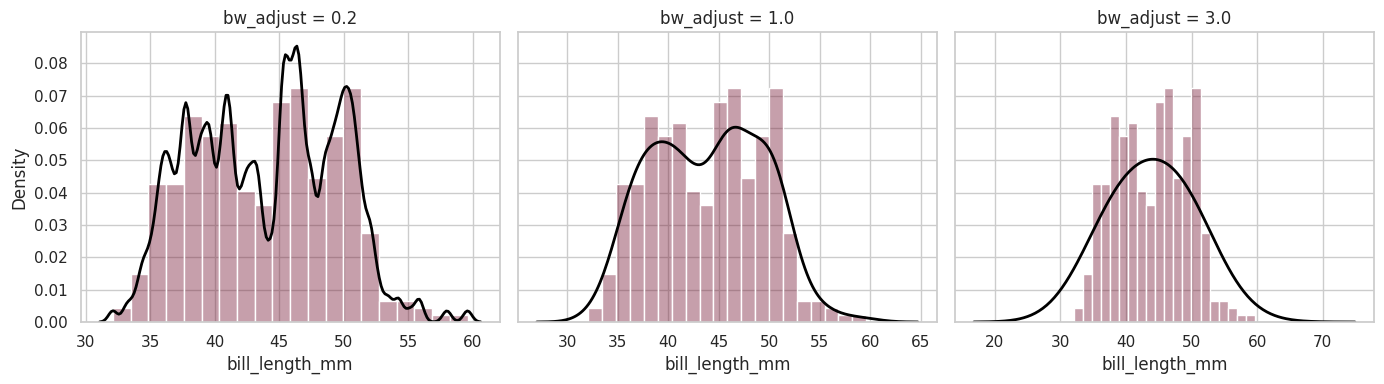

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, bw in zip(axes, [0.2, 1.0, 3.0]):
    sns.histplot(bill_length, bins=20, stat="density", color="#72112D", alpha=0.4, ax=ax)
    sns.kdeplot(bill_length, bw_adjust=bw, color="black", linewidth=2, ax=ax)
    ax.set_title(f"bw_adjust = {bw}")

plt.tight_layout()
plt.show()


**Interpretation:** with a small bandwidth (`bw_adjust=0.2`) the KDE chases every bump in the histogram — noisy, likely overfit to this particular sample. With a large bandwidth (`bw_adjust=3.0`) it oversmooths into a single wide hump, potentially hiding real structure. The middle setting is a reasonable compromise. There's no universally "correct" bandwidth — it's a judgment call, same as histogram bin width.


## Boxplot

A boxplot summarizes a distribution with five numbers: $Q_1$, median, $Q_3$, and the whisker range. Let's compare `body_mass_g` across species — this is where a boxplot earns its keep, since comparing several groups side by side in histogram form gets cluttered fast.

**Boxplots are the right tool when the question is about central tendency and spread** — comparing medians and IQRs across groups at a glance. That's a different question from the one we asked in the Multimodality section above, and it's worth being explicit about the trade-off: a boxplot will *not* reveal that a group's distribution has multiple peaks, because the five summary numbers it plots don't carry that information. If you need to compare typical values across species, reach for a boxplot; if you need to check whether a species' distribution is itself multimodal, go back to an overlaid histogram or KDE.


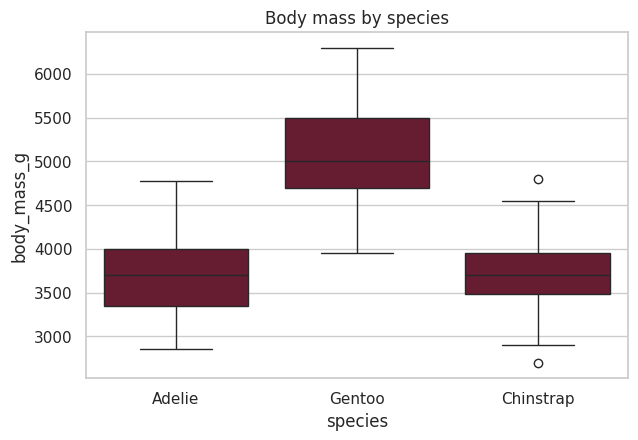

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=penguins, x="species", y="body_mass_g", color="#72112D", ax=ax)
ax.set_title("Body mass by species")
plt.show()


**Interpretation:** Gentoo penguins have a visibly higher median body mass than Adelie or Chinstrap, and their box (the IQR) sits well above the other two with little overlap — consistent with the separate peak we saw in the multimodality histogram. Adelie and Chinstrap have similar medians and overlapping boxes, meaning body mass alone wouldn't reliably distinguish those two species. Any dots beyond the whiskers flag individual penguins that are unusually heavy or light *for their species*.


## Catplot

`sns.catplot()` is seaborn's general-purpose interface for **categorical plots** — it can draw boxplots, violin plots, strip plots, and more, all through one function by changing the `kind` argument. Unlike `sns.boxplot()` (an *axes-level* function — draws onto one set of axes you provide), `catplot()` is a *figure-level* function — it manages its own figure and can automatically create small multiples (facets) by category.


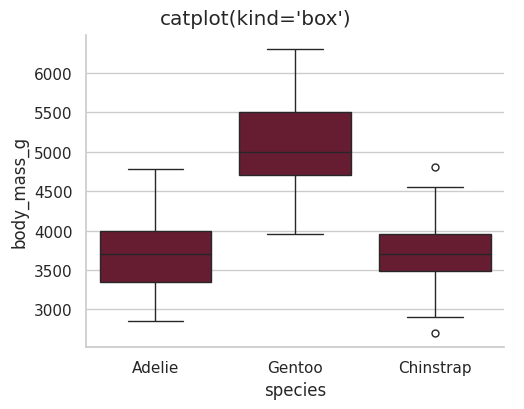

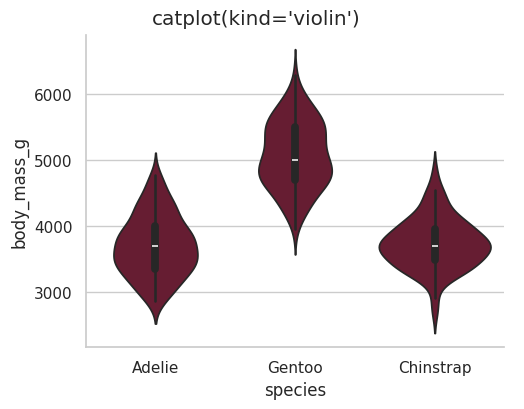

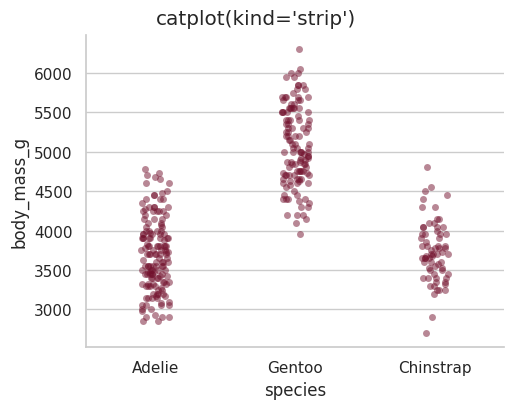

In [13]:
sns.catplot(data=penguins, x="species", y="body_mass_g", kind="box",
            height=4, aspect=1.3, color="#72112D")
plt.suptitle("catplot(kind='box')", y=1.02)
plt.show()

sns.catplot(data=penguins, x="species", y="body_mass_g", kind="violin",
            height=4, aspect=1.3, color="#72112D")
plt.suptitle("catplot(kind='violin')", y=1.02)
plt.show()

sns.catplot(data=penguins, x="species", y="body_mass_g", kind="strip",
            height=4, aspect=1.3, color="#72112D", alpha=0.5)
plt.suptitle("catplot(kind='strip')", y=1.02)
plt.show()


**Interpretation:** all three plots show the same underlying data. The **box** version (same as our boxplot above) is compact and good for reading off quartiles. The **violin** version mirrors a KDE on each side of the box — it recovers shape detail (like Gentoo's fairly symmetric spread) that a boxplot's five numbers alone can't show. The **strip** version plots every individual penguin as a point, trading summary clarity for showing you the raw data and sample size directly — notice there are visibly more Adelie penguins than Chinstrap. Which one to use depends on whether you want compactness, shape, or the raw observations.

This is the same trade-off from the Boxplot section, made adjustable: `catplot(kind='box')` gets you the central-tendency comparison; `catplot(kind='violin')` gets some of the shape/modality information back (at the cost of being slightly harder to read precisely); `catplot(kind='strip')` gives up summarization entirely in exchange for showing you everything, including sample size per group. None of the three is strictly "better" — the right one depends on which question (central tendency, shape, or raw data) you're actually asking.

## Choosing the Right Plot

We've now covered five ways to visualize a distribution, each suited to a different question. It's worth pulling that together in one place before moving on:

| Question | Best tool | Why |
|---|---|---|
| What's the typical value, and how do groups compare? | **Boxplot** (or `catplot(kind='box')`) | Median and IQR are read directly off the box; compact enough to compare many groups side by side |
| Does this distribution have more than one peak? | **Overlaid / `hue`-split histogram or KDE** | Peaks are visible directly on the curve/bars; a boxplot's five summary numbers can't show this |
| What's the overall shape (symmetric? skewed? heavy-tailed?) | **Histogram + KDE** | The full curve is visible, not just five summary points |
| I want the shape *and* a group comparison | **`catplot(kind='violin')`** | Mirrors a KDE on each side of a box — some shape detail, still grouped |
| I don't trust any summary and want to see every observation | **`catplot(kind='strip')`** | No summarization at all — also reveals sample size per group |

The common thread: **every summary — a mean, a median, a box — throws away some information to make the rest easier to read.** Which information you can afford to lose depends entirely on the question you're asking. This is the same idea from Lesson 1.4's opening slide on Reductionism, now made concrete: choosing a plot type *is* choosing what to keep and what to discard.


## Preview: Frequency in Two Dimensions

Everything above counted frequency for **one** feature at a time. What if we count frequency for **two** features jointly? The same histogram-vs-KDE relationship holds one dimension up:

- A **2D histogram** bins two continuous features into a grid and counts how many observations fall in each grid cell (color = count).
- A **contour plot** is what you get if you smooth that grid the same way a KDE smooths a 1D histogram.

This is genuinely a preview, not a full lesson — **this is where Notebook 01-04: Correlation Analysis picks up**, since jointly counting two features is really asking "how do these two features relate?"


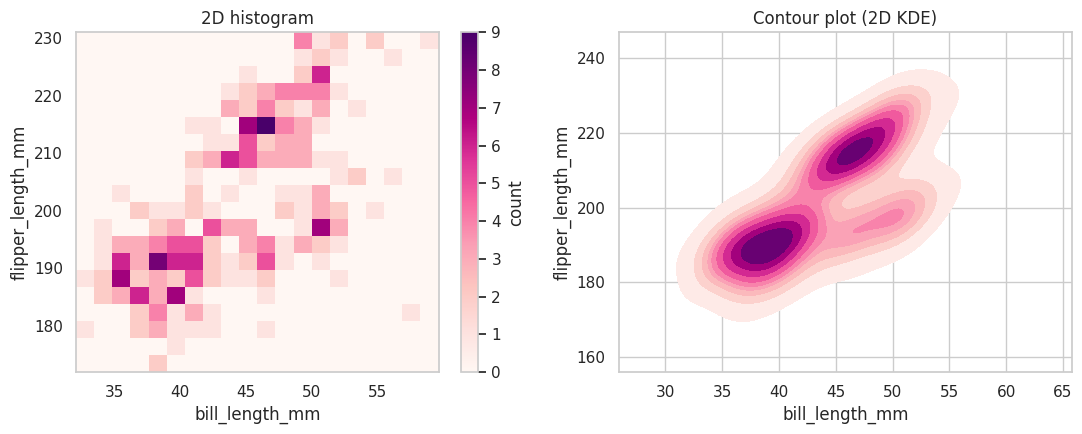

In [14]:
bivariate = penguins[["bill_length_mm", "flipper_length_mm"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# 2D histogram: binned joint counts
h = axes[0].hist2d(bivariate["bill_length_mm"], bivariate["flipper_length_mm"],
                    bins=20, cmap="RdPu")
fig.colorbar(h[3], ax=axes[0], label="count")
axes[0].set_title("2D histogram")
axes[0].set_xlabel("bill_length_mm")
axes[0].set_ylabel("flipper_length_mm")

# Contour plot: the smoothed version of the same joint distribution
sns.kdeplot(data=bivariate, x="bill_length_mm", y="flipper_length_mm",
            fill=True, cmap="RdPu", ax=axes[1])
axes[1].set_title("Contour plot (2D KDE)")

plt.tight_layout()
plt.show()


**Interpretation:** both plots show the same joint pattern — most penguins cluster in one region, with a visible second cluster of longer bills and longer flippers together. That's already a hint that these two features move together — which is exactly what correlation analysis formalizes next notebook.


## Independent Practice Activity: Restaurant Tips

Now practice on a new dataset: `tips` (from seaborn's built-in example datasets) — records of restaurant bills, tips, and details about each table.

**Do not use correlation for this activity** — that's next notebook. Focus on the frequency and distribution tools from this notebook.


In [15]:
tips = sns.load_dataset("tips")
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [16]:
tips.dtypes


,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


**Try it yourself.** Using the cells below as a starting point, work through the following:

1. Compute the mean, median, and mode of `total_bill`, by hand and with pandas. Are mean and median close together, or far apart? What might that suggest about the shape?
2. `day` is a discrete/categorical feature and `total_bill` is continuous. Plot both (a count plot for `day`, a histogram for `total_bill`) and explain in a markdown cell why they look different.
3. Compute the skewness of `total_bill`. Does the sign match what you predicted in Question 1?
4. Build a boxplot of `tip` grouped by `day`. Which day has the widest spread? Are there any outliers?
5. Build a `catplot` of `total_bill` by `time` (Lunch/Dinner) using `kind="violin"`. What does the shape tell you that a boxplot wouldn't?

Some starter cells are provided below — extend them as needed.


In [17]:
# 1. Central tendency of total_bill
# (fill in: by hand and with pandas)



In [18]:
# 2. Discrete (day) vs. continuous (total_bill) plots



In [19]:
# 3. Skewness of total_bill



In [20]:
# 4. Boxplot of tip by day



In [21]:
# 5. Catplot of total_bill by time, kind='violin'



## Recap

In this notebook, we covered:

- **Central tendency** — mean, median, mode, computed by hand and with pandas
- **Discrete vs. continuous histograms** — why gapped bar charts and contiguous histograms represent genuinely different kinds of data
- **Multimodality** — recreating the lecture's three-peaks-from-three-species example
- **Skewness & kurtosis** — computed with `scipy.stats`, and checked visually against a fitted Gaussian
- **The distribution-visualization toolkit** — histogram, KDE (and bandwidth), boxplot, and `catplot`'s box/violin/strip variants
- **A first look at two dimensions** — 2D histograms and contour plots, previewing Correlation Analysis

**Next up:** **Notebook 01-04: Correlation Analysis** covers covariance, Pearson's $r$, Spearman's rank correlation, correlation heatmaps, and why correlation isn't causation — picking up right where the 2D histogram preview left off. A companion **Lab Activity** for correlation analysis is also available.
